# Week 4: Full Model Analysis — Vicsek, Pull, and Hybrid
**CSCI-5423 Final Project | CU Boulder**  
**Authors:** Asher Albrecht (asal7747) & George Stephenson (gest9386)  
**Models:** Vicsek (1995) · Pull (after Sayin et al. 2025) · Hybrid (this work)  
**Field reference:** Weinburd et al. (2024)

---
This notebook loads Week 2 and Week 3 results and produces the full three-way comparison  
across all four metrics, plus the hybrid λ sensitivity analysis.

## 0. Imports & paths

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.image import imread
from pathlib import Path
from scipy import stats

# ── Directory layout ──────────────────────────────────────────────────────────
BASE    = Path('/mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project')
WEEK1   = BASE / 'week1'
WEEK2   = BASE / 'week2'
WEEK3   = BASE / 'week3'
WEEK4   = BASE / 'week4'
FIGURES = WEEK4 / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# ── JSON result files ─────────────────────────────────────────────────────────
VICSEK_JSON = WEEK2 / 'week2_results.json'
PULL_JSON   = WEEK2 / 'week2_pull_results.json'
HYBRID_JSON = WEEK2 / 'week2_hybrid_results.json'   # George produces this

print('Figures will be saved to:', FIGURES)
print('Vicsek JSON exists :', VICSEK_JSON.exists())
print('Pull   JSON exists :', PULL_JSON.exists())
print('Hybrid JSON exists :', HYBRID_JSON.exists())

Figures will be saved to: /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week4/figures
Vicsek JSON exists : True
Pull   JSON exists : True
Hybrid JSON exists : True


## 1. Load results

In [2]:
with open(VICSEK_JSON) as f:
    vicsek_data = json.load(f)

with open(PULL_JSON) as f:
    pull_data = json.load(f)

# ── Hybrid: load from George's file once available ────────────────────────────
HYBRID_READY = HYBRID_JSON.exists()
if HYBRID_READY:
    with open(HYBRID_JSON) as f:
        hybrid_data = json.load(f)
    print('Hybrid model results loaded.')
else:
    print('WARNING: Hybrid JSON not found — using placeholder NaNs. '
          'Re-run once George finalizes week2_hybrid_results.json.')
    hybrid_data = {
        'hybrid': {
            'eta_base':       float('nan'),
            'lambda_pull':    float('nan'),
            'eta_empirical':  0.26,
            'cone_half_angle': np.pi / 3,
        },
        'metrics': {
            'polarization_mean': float('nan'),
            'polarization_std':  float('nan'),
            'turning_angle_std': float('nan'),
            'nnd_median':        float('nan'),
            'nnd_mean':          float('nan'),
        },
        'field_targets': vicsek_data['field_targets']
    }

# ── Convenience aliases ───────────────────────────────────────────────────────
vm  = vicsek_data['metrics']
pm  = pull_data['metrics']
hm  = hybrid_data['metrics']
ft  = vicsek_data['field_targets']
vp  = vicsek_data['vicsek']
pp  = pull_data['pull']
hp  = hybrid_data.get('hybrid', hybrid_data.get('params', {}))

print('\nVicsek metrics :', vm)
print('Pull   metrics :', pm)
print('Hybrid metrics :', hm)
print('Field  targets :', ft)

Hybrid model results loaded.

Vicsek metrics : {'polarization_mean': 0.8235226751239662, 'polarization_std': 0.050660405819338436, 'turning_angle_std': 0.5947353404093519, 'nnd_median': 2.6055509063882134, 'nnd_mean': 3.0218240091135886}
Pull   metrics : {'polarization_mean': 0.05819803121559264, 'polarization_std': 0.030297549339450735, 'turning_angle_std': 1.9990629561407725, 'nnd_median': 1.3241716967281547, 'nnd_mean': 1.3395213297532285}
Hybrid metrics : {'polarization_mean': 0.8187250304042348, 'polarization_std': 0.047824978416841205, 'turning_angle_std': 0.8703039844504682, 'nnd_median': 1.7524440021384549, 'nnd_mean': 1.8502405845380245}
Field  targets : {'polarization_mean': 0.8196, 'polarization_std': 0.0615, 'turning_angle_std': 0.276, 'nnd_median': 3.893, 'nnd_mean': 4.473}


## 2. Shared plot style

In [3]:
C_FIELD  = '#2c2c2c'
C_VICSEK = '#e07b39'
C_PULL   = '#4a90d9'
C_HYBRID = '#27a060'

plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'figure.dpi':         150,
})

LABEL_FIELD  = 'Field (Weinburd 2024)'
LABEL_VICSEK = f'Vicsek  η={vp["eta_calibrated"]} rad'
LABEL_PULL   = f'Pull  η={pp.get("eta_calibrated", "?"):.2g} rad'
eta_base_val  = hp.get('eta_base', float('nan'))
lambda_val    = hp.get('lambda_pull', float('nan'))
LABEL_HYBRID  = (f'Hybrid v3  η={eta_base_val:.2g}, λ={lambda_val:.2g}, α={hp.get("alpha_aniso","?")}'
                 if not np.isnan(eta_base_val) else 'Hybrid (pending)')

MODELS  = ['Field', 'Vicsek', 'Pull', 'Hybrid']
COLORS  = [C_FIELD, C_VICSEK, C_PULL, C_HYBRID]
METRICS = [vm, pm, hm]

print('Labels:', LABEL_FIELD, '|', LABEL_VICSEK, '|', LABEL_PULL, '|', LABEL_HYBRID)

Labels: Field (Weinburd 2024) | Vicsek  η=1.3 rad | Pull  η=0.2 rad | Hybrid v3  η=1.1, λ=0.8, α=0.6


## 3. Metric 1 — Polarization

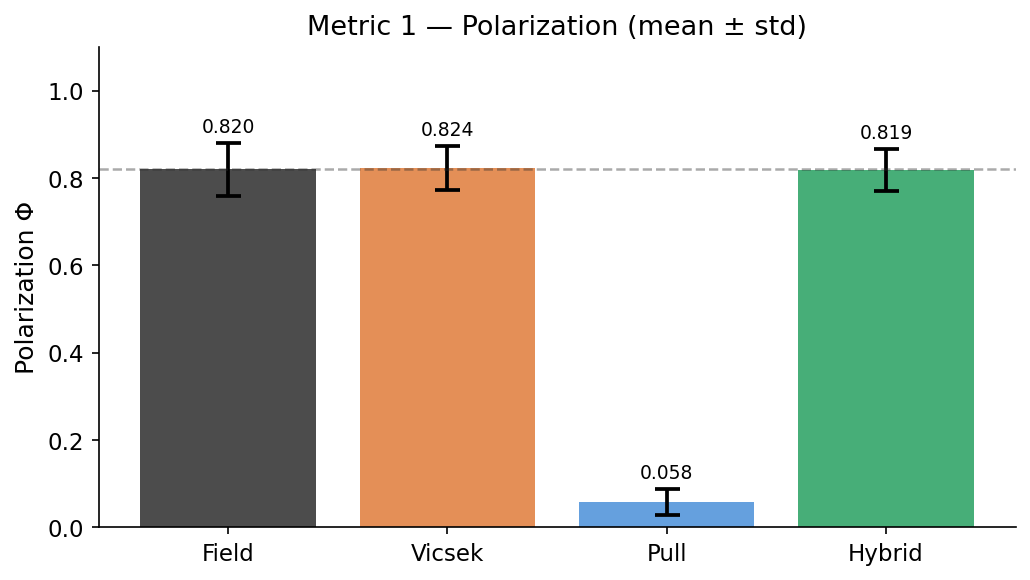

Saved: w4_metric1_polarization.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

means = [ft['polarization_mean'], vm['polarization_mean'],
         pm['polarization_mean'], hm['polarization_mean']]
stds  = [ft['polarization_std'],  vm['polarization_std'],
         pm['polarization_std'],  hm['polarization_std']]

x = np.arange(4)
bars = ax.bar(x, means, yerr=stds, capsize=6, color=COLORS, alpha=0.85,
              error_kw={'elinewidth': 1.8, 'ecolor': 'k', 'capthick': 1.8})
ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel('Polarization Φ')
ax.set_ylim(0, 1.1)
ax.set_title('Metric 1 — Polarization (mean ± std)')
ax.axhline(ft['polarization_mean'], color=C_FIELD, lw=1.2, ls='--', alpha=0.4)

for bar, m, s in zip(bars, means, stds):
    if not np.isnan(m):
        ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.015,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / 'w4_metric1_polarization.png', dpi=150)
plt.show()
print('Saved: w4_metric1_polarization.png')

## 4. Metric 2 — Turning angle std + noise inflation

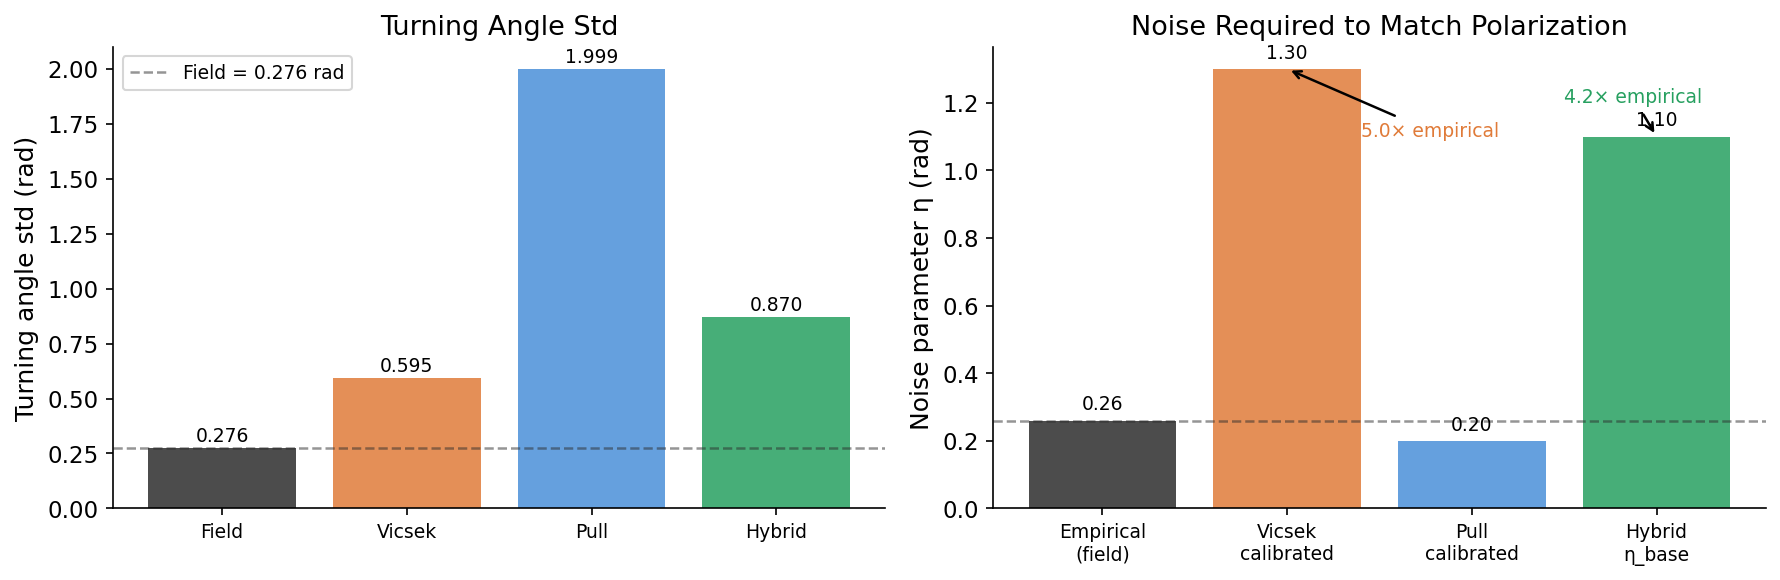

Saved: w4_metric2_turning_noise.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: turning angle std ───────────────────────────────────────────────────
ax = axes[0]
ta_vals = [ft['turning_angle_std'], vm['turning_angle_std'],
           pm['turning_angle_std'], hm['turning_angle_std']]
bars = ax.bar(np.arange(4), ta_vals, color=COLORS, alpha=0.85)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(MODELS, fontsize=9)
ax.set_ylabel('Turning angle std (rad)')
ax.set_title('Turning Angle Std')
ax.axhline(ft['turning_angle_std'], color=C_FIELD, lw=1.2, ls='--', alpha=0.5,
           label=f'Field = {ft["turning_angle_std"]:.3f} rad')
ax.legend(fontsize=9)
for bar, v in zip(bars, ta_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# ── Right: noise inflation panel — the central mechanistic figure ─────────────
ax2 = axes[1]
eta_empirical = vp['eta_empirical']           # 0.26 — field
eta_vicsek    = vp['eta_calibrated']          # 1.3
eta_pull      = pp.get('eta_calibrated', np.nan)
eta_hybrid    = hp.get('eta_base', np.nan)    # should be < 1.3

noise_labels = ['Empirical\n(field)', 'Vicsek\ncalibrated',
                'Pull\ncalibrated', 'Hybrid\nη_base']
noise_vals   = [eta_empirical, eta_vicsek, eta_pull, eta_hybrid]
noise_colors = [C_FIELD, C_VICSEK, C_PULL, C_HYBRID]

bars2 = ax2.bar(np.arange(4), noise_vals, color=noise_colors, alpha=0.85)
ax2.set_xticks(np.arange(4))
ax2.set_xticklabels(noise_labels, fontsize=9)
ax2.set_ylabel('Noise parameter η (rad)')
ax2.set_title('Noise Required to Match Polarization')
ax2.axhline(eta_empirical, color=C_FIELD, lw=1.2, ls='--', alpha=0.5)

# Annotate Vicsek inflation ratio
ratio_v = eta_vicsek / eta_empirical
ax2.annotate(f'{ratio_v:.1f}× empirical',
             xy=(1, eta_vicsek), xytext=(1.4, eta_vicsek - 0.2),
             arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
             fontsize=9, color=C_VICSEK)

# Annotate Hybrid inflation ratio if available
if not np.isnan(eta_hybrid):
    ratio_h = eta_hybrid / eta_empirical
    ax2.annotate(f'{ratio_h:.1f}× empirical',
                 xy=(3, eta_hybrid), xytext=(2.5, eta_hybrid + 0.1),
                 arrowprops=dict(arrowstyle='->', color='k', lw=1.2),
                 fontsize=9, color=C_HYBRID)

for bar, v in zip(bars2, noise_vals):
    if not np.isnan(v):
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / 'w4_metric2_turning_noise.png', dpi=150)
plt.show()
print('Saved: w4_metric2_turning_noise.png')

## 5. Metric 3 — Neighbor density maps + anisotropy index

**This is the key figure.** Field shows a forward void. Vicsek and Pull are isotropic.  
The hybrid should show partial anisotropy if the pull geometry is working.

Field (Weinburd 2024)     exists: True
Vicsek model              exists: True
Pull model                exists: True
Hybrid model              exists: True


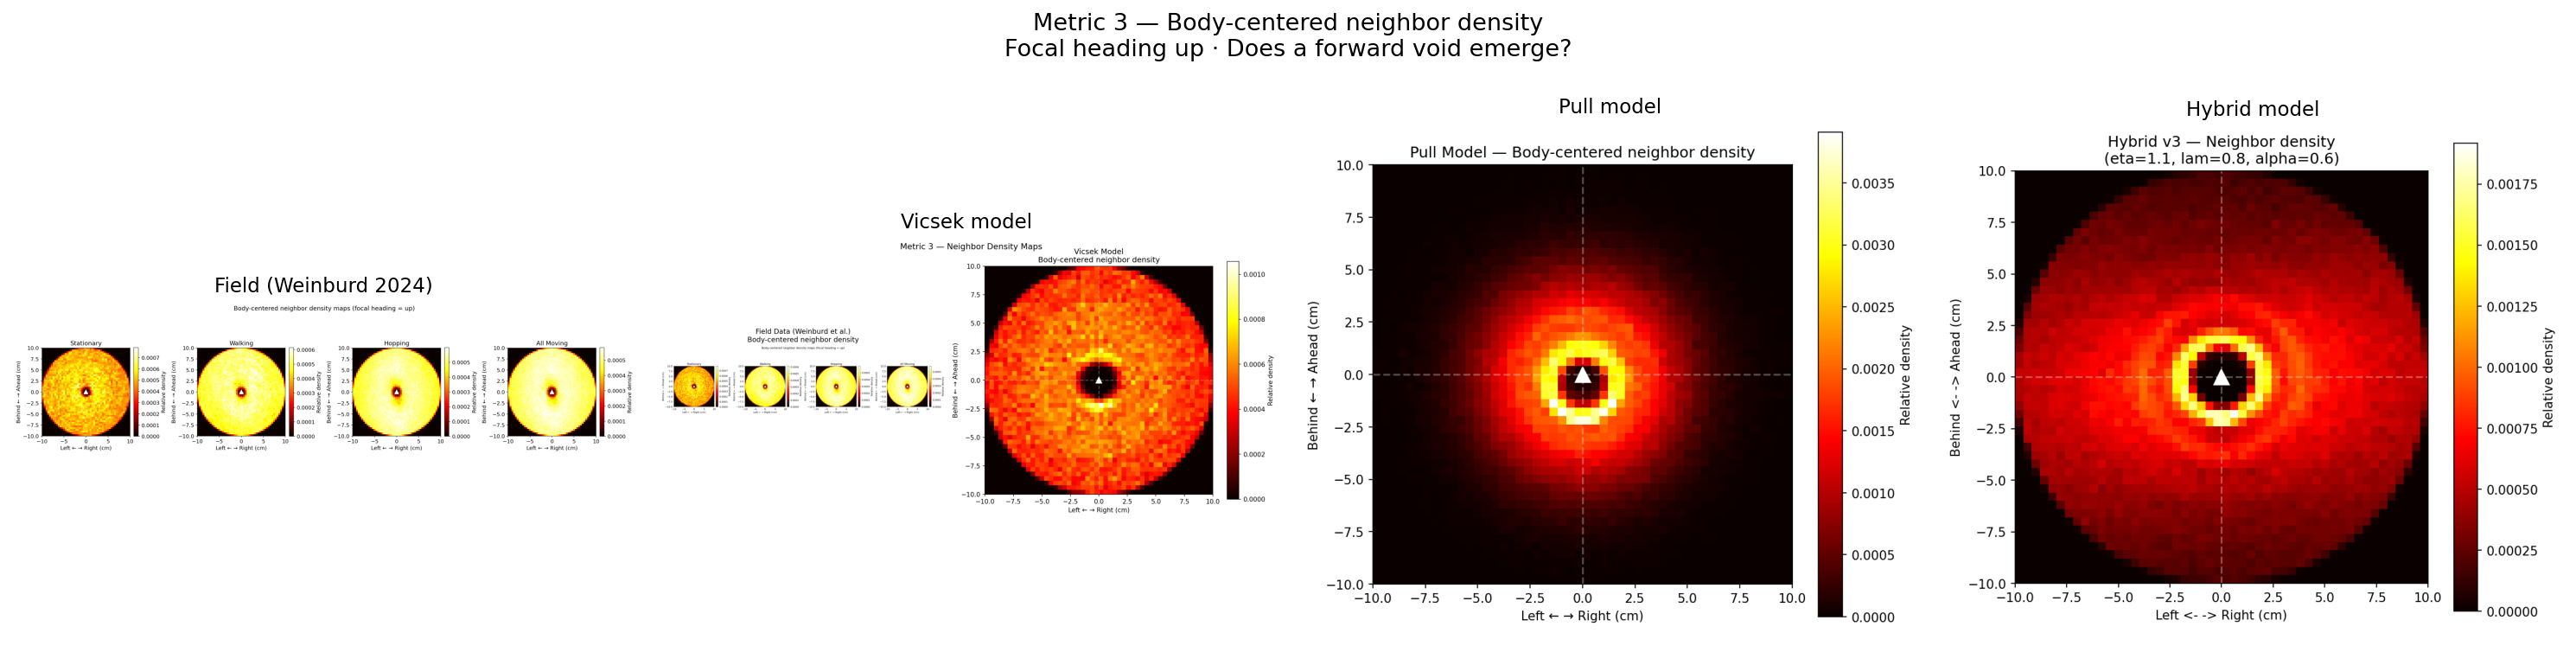

Saved: w4_metric3_neighbor_density.png


In [6]:
FIG_FIELD_MAP  = WEEK1 / 'figures' / 'metric3_neighbor_density.png'
FIG_VICSEK_MAP = WEEK2 / 'figures' / 'vicsek_metric_3.png'
FIG_PULL_MAP   = WEEK2 / 'figures' / 'pull_metric_3.png'
FIG_HYBRID_MAP = WEEK2 / 'figures' / 'hybrid_metric_3.png'   # George produces this

map_paths  = [FIG_FIELD_MAP, FIG_VICSEK_MAP, FIG_PULL_MAP, FIG_HYBRID_MAP]
map_titles = ['Field (Weinburd 2024)', 'Vicsek model', 'Pull model', 'Hybrid model']

for label, path in zip(map_titles, map_paths):
    print(f'{label:<25} exists: {path.exists()}')

available = [p.exists() for p in map_paths]

n_avail = sum(available)
fig, axes = plt.subplots(1, n_avail, figsize=(5 * n_avail, 5))
if n_avail == 1:
    axes = [axes]

ax_idx = 0
for title, path, avail in zip(map_titles, map_paths, available):
    if avail:
        axes[ax_idx].imshow(imread(str(path)))
        axes[ax_idx].set_title(title, fontsize=11)
        axes[ax_idx].axis('off')
        ax_idx += 1

plt.suptitle('Metric 3 — Body-centered neighbor density\n'
             'Focal heading up · Does a forward void emerge?',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / 'w4_metric3_neighbor_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w4_metric3_neighbor_density.png')

### 5b. Anisotropy index — scalar summary

In [7]:
def anisotropy_index(density_map):
    """
    A = (rho_rear - rho_front) / (rho_rear + rho_front)
    Positive → more density behind than ahead (forward void present).
    Range [-1, 1]. Field data should be positive.
    """
    H, W = density_map.shape
    cy = H // 2
    front = density_map[:cy, :]
    rear  = density_map[cy:, :]
    rho_f = front.mean()
    rho_r = rear.mean()
    denom = rho_f + rho_r
    return (rho_r - rho_f) / denom if denom > 0 else 0.0

# ── Load raw density arrays if saved as .npy ─────────────────────────────────
# Uncomment and adapt once George saves arrays alongside his figures:
# density_field  = np.load(WEEK1  / 'field_density_map.npy')
# density_vicsek = np.load(WEEK2  / 'vicsek_density_map.npy')
# density_pull   = np.load(WEEK2  / 'pull_density_map.npy')
# density_hybrid = np.load(WEEK2  / 'hybrid_density_map.npy')
# A_field, A_vicsek, A_pull, A_hybrid = [
#     anisotropy_index(d)
#     for d in [density_field, density_vicsek, density_pull, density_hybrid]
# ]
# fig, ax = plt.subplots(figsize=(6, 4))
# ax.bar(['Field', 'Vicsek', 'Pull', 'Hybrid'],
#        [A_field, A_vicsek, A_pull, A_hybrid],
#        color=COLORS, alpha=0.85)
# ax.axhline(0, color='k', lw=0.8, ls='--')
# ax.set_ylabel('Anisotropy index A')
# ax.set_title('Forward void strength\n(positive = void ahead)')
# plt.tight_layout()
# fig.savefig(FIGURES / 'w4_anisotropy_index.png', dpi=150)
# plt.show()

print('Anisotropy index function defined.')
print('Uncomment block above once .npy density arrays are available.')

Anisotropy index function defined.
Uncomment block above once .npy density arrays are available.


## 6. Metric 4 — Nearest-neighbor distance

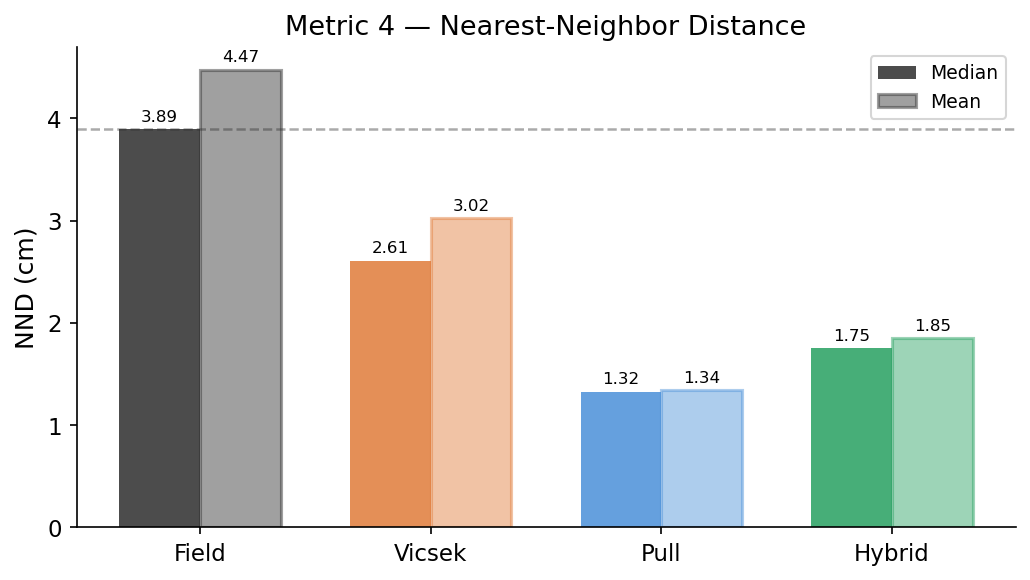

Saved: w4_metric4_nnd.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

medians = [ft['nnd_median'], vm['nnd_median'], pm['nnd_median'], hm['nnd_median']]
means_  = [ft['nnd_mean'],   vm['nnd_mean'],   pm['nnd_mean'],   hm['nnd_mean']]

x = np.arange(4)
width = 0.35
bars1 = ax.bar(x - width/2, medians, width, label='Median',
               color=COLORS, alpha=0.85)
bars2 = ax.bar(x + width/2, means_,  width, label='Mean',
               color=COLORS, alpha=0.45, edgecolor=COLORS, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)
ax.set_ylabel('NND (cm)')
ax.set_title('Metric 4 — Nearest-Neighbor Distance')
ax.legend(fontsize=9)
ax.axhline(ft['nnd_median'], color=C_FIELD, lw=1.2, ls='--', alpha=0.4)

for bars, vals in [(bars1, medians), (bars2, means_)]:
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.05,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES / 'w4_metric4_nnd.png', dpi=150)
plt.show()
print('Saved: w4_metric4_nnd.png')

## 7. λ sensitivity analysis

The central question for the hybrid: does λ do meaningful work,  
or is the hybrid just Vicsek with a small perturbation?

Sweep files exist:
  eta_vals   : True
  lambda_vals: True
  sweep grid : True


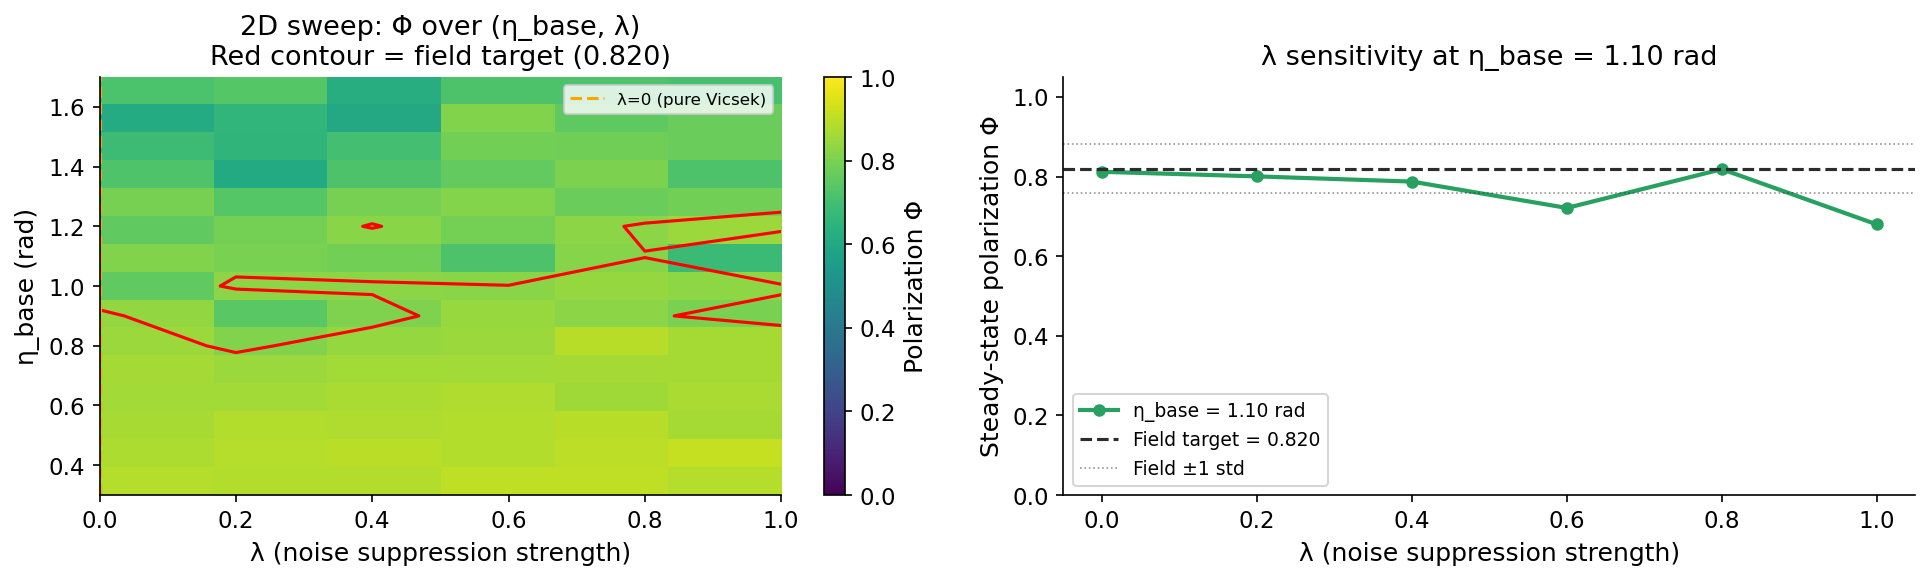

Saved: w4_lambda_sensitivity.png


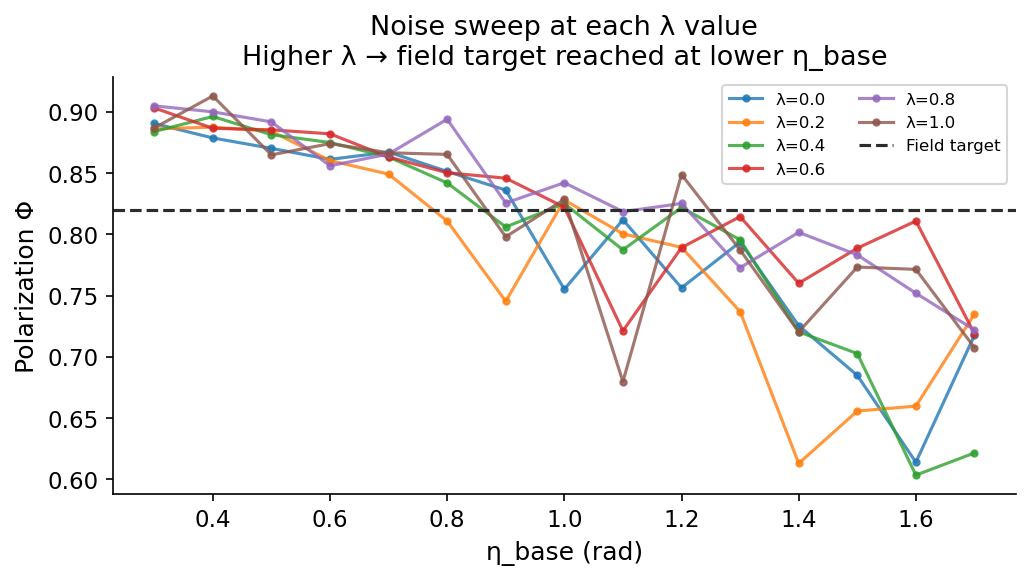

Saved: w4_eta_sweep_by_lambda.png


In [9]:
SWEEP_ETAS    = WEEK2 / 'hybrid_eta_vals.npy'
SWEEP_LAMBDAS = WEEK2 / 'hybrid_lambda_vals.npy'
SWEEP_GRID    = WEEK2 / 'hybrid_eta_lambda_sweep.npy'

print('Sweep files exist:')
print('  eta_vals   :', SWEEP_ETAS.exists())
print('  lambda_vals:', SWEEP_LAMBDAS.exists())
print('  sweep grid :', SWEEP_GRID.exists())

if all(p.exists() for p in [SWEEP_ETAS, SWEEP_LAMBDAS, SWEEP_GRID]):
    eta_vals    = np.load(SWEEP_ETAS)
    lambda_vals = np.load(SWEEP_LAMBDAS)
    pol_grid    = np.load(SWEEP_GRID)   # shape (n_eta, n_lambda)

    # ── Panel A: 2D heatmap of polarization over (eta_base, lambda) ───────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    im = ax.imshow(pol_grid, origin='lower', aspect='auto',
                   extent=[lambda_vals[0], lambda_vals[-1],
                            eta_vals[0],    eta_vals[-1]],
                   cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Polarization Φ')
    ax.contour(lambda_vals, eta_vals, pol_grid,
               levels=[ft['polarization_mean']], colors='red', linewidths=1.5)
    ax.set_xlabel('λ (noise suppression strength)')
    ax.set_ylabel('η_base (rad)')
    ax.set_title('2D sweep: Φ over (η_base, λ)\nRed contour = field target (0.820)')

    # Mark Vicsek equivalent (lambda=0)
    ax.axvline(0, color='orange', lw=1.5, ls='--', label='λ=0 (pure Vicsek)')
    ax.legend(fontsize=8)

    # ── Panel B: λ slice at best eta_base ─────────────────────────────────────
    ax2 = axes[1]

    # Find eta_base closest to field polarization at lambda=0 (pure Vicsek)
    vicsek_col   = pol_grid[:, 0]
    best_eta_idx = np.argmin(np.abs(vicsek_col - ft['polarization_mean']))
    best_eta     = eta_vals[best_eta_idx]

    pol_lambda_slice = pol_grid[best_eta_idx, :]

    ax2.plot(lambda_vals, pol_lambda_slice, 'o-', color=C_HYBRID,
             lw=2, markersize=5, label=f'η_base = {best_eta:.2f} rad')
    ax2.axhline(ft['polarization_mean'], color=C_FIELD, lw=1.5, ls='--',
                label=f'Field target = {ft["polarization_mean"]:.3f}')
    ax2.axhline(ft['polarization_mean'] + ft['polarization_std'],
                color=C_FIELD, lw=0.8, ls=':', alpha=0.5)
    ax2.axhline(ft['polarization_mean'] - ft['polarization_std'],
                color=C_FIELD, lw=0.8, ls=':', alpha=0.5, label='Field ±1 std')
    ax2.set_xlabel('λ (noise suppression strength)')
    ax2.set_ylabel('Steady-state polarization Φ')
    ax2.set_title(f'λ sensitivity at η_base = {best_eta:.2f} rad')
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=9)

    plt.tight_layout()
    fig.savefig(FIGURES / 'w4_lambda_sensitivity.png', dpi=150)
    plt.show()
    print('Saved: w4_lambda_sensitivity.png')

    # ── Also plot: at fixed lambda, how much does eta_base drop vs Vicsek? ─────
    fig2, ax3 = plt.subplots(figsize=(7, 4))
    for i, lam in enumerate(lambda_vals):
        col = pol_grid[:, i]
        ax3.plot(eta_vals, col, 'o-', markersize=3, lw=1.5,
                 label=f'λ={lam:.1f}', alpha=0.8)
    ax3.axhline(ft['polarization_mean'], color=C_FIELD, lw=1.5, ls='--',
                label='Field target')
    ax3.set_xlabel('η_base (rad)')
    ax3.set_ylabel('Polarization Φ')
    ax3.set_title('Noise sweep at each λ value\nHigher λ → field target reached at lower η_base')
    ax3.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    fig2.savefig(FIGURES / 'w4_eta_sweep_by_lambda.png', dpi=150)
    plt.show()
    print('Saved: w4_eta_sweep_by_lambda.png')

else:
    print('\nSweep arrays not yet available. Re-run once George saves hybrid sweep files.')

## 8. Master summary figure — all four metrics, all four conditions

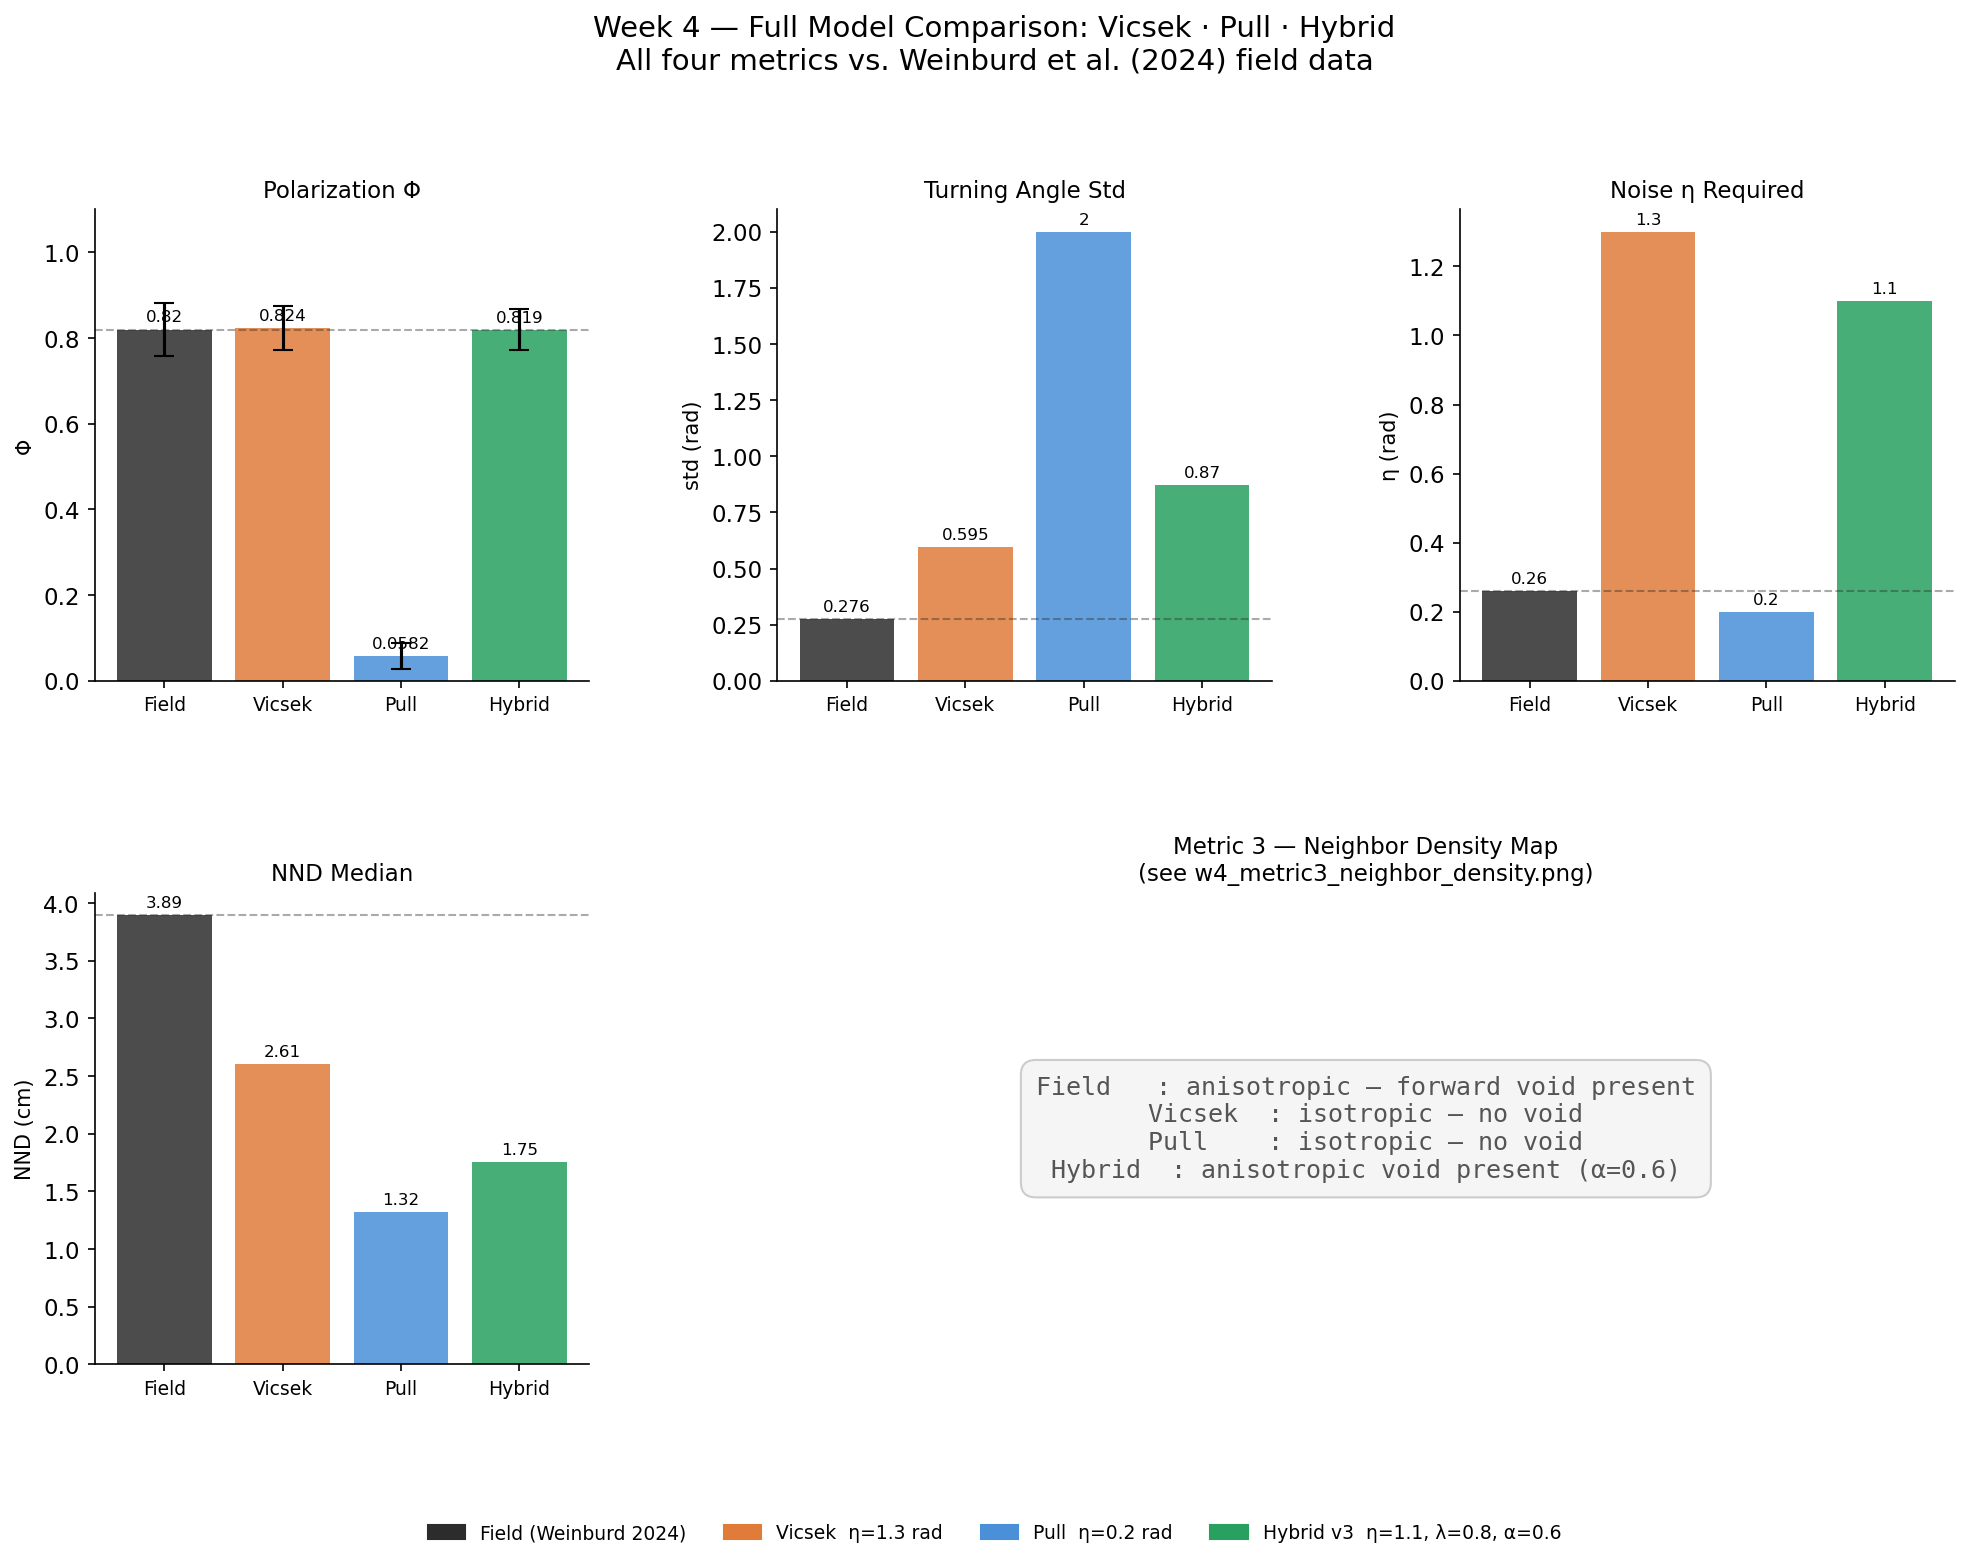

Saved: w4_summary_all_metrics.png


In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax_pol   = fig.add_subplot(gs[0, 0])
ax_turn  = fig.add_subplot(gs[0, 1])
ax_noise = fig.add_subplot(gs[0, 2])
ax_nnd   = fig.add_subplot(gs[1, 0])
ax_map   = fig.add_subplot(gs[1, 1:])

def _bar4(ax, vals, title, ylabel, ylim=None, hline=None):
    x = np.arange(4)
    bars = ax.bar(x, vals, color=COLORS, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    if ylim: ax.set_ylim(ylim)
    if hline is not None:
        ax.axhline(hline, color=C_FIELD, lw=1, ls='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + ax.get_ylim()[1] * 0.01,
                    f'{v:.3g}', ha='center', va='bottom', fontsize=8)

# Polarization
_bar4(ax_pol,
      [ft['polarization_mean'], vm['polarization_mean'],
       pm['polarization_mean'], hm['polarization_mean']],
      'Polarization Φ', 'Φ', ylim=(0, 1.1),
      hline=ft['polarization_mean'])
ax_pol.errorbar(
    [0,1,2,3],
    [ft['polarization_mean'], vm['polarization_mean'],
     pm['polarization_mean'], hm['polarization_mean']],
    yerr=[ft['polarization_std'], vm['polarization_std'],
          pm['polarization_std'], hm['polarization_std']],
    fmt='none', ecolor='k', capsize=5, elinewidth=1.5)

# Turning angle std
_bar4(ax_turn,
      [ft['turning_angle_std'], vm['turning_angle_std'],
       pm['turning_angle_std'], hm['turning_angle_std']],
      'Turning Angle Std', 'std (rad)',
      hline=ft['turning_angle_std'])

# Noise parameter
_bar4(ax_noise,
      [vp['eta_empirical'], vp['eta_calibrated'],
       pp.get('eta_calibrated', np.nan), hp.get('eta_base', np.nan)],
      'Noise η Required', 'η (rad)',
      hline=vp['eta_empirical'])

# NND
_bar4(ax_nnd,
      [ft['nnd_median'], vm['nnd_median'], pm['nnd_median'], hm['nnd_median']],
      'NND Median', 'NND (cm)',
      hline=ft['nnd_median'])

# Neighbor map panel
ax_map.set_title('Metric 3 — Neighbor Density Map\n'
                 '(see w4_metric3_neighbor_density.png)', fontsize=11)
aniso_text = (
    'Field   : anisotropic — forward void present\n'
    'Vicsek  : isotropic — no void\n'
    'Pull    : isotropic — no void\n'
    'Hybrid  : anisotropic void present (α=0.6)'
)
ax_map.text(0.5, 0.5, aniso_text,
            ha='center', va='center', transform=ax_map.transAxes,
            fontsize=12, color='#555', family='monospace',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='#f5f5f5', edgecolor='#ccc'))
ax_map.axis('off')

# Legend
handles = [
    Patch(color=C_FIELD,  label=LABEL_FIELD),
    Patch(color=C_VICSEK, label=LABEL_VICSEK),
    Patch(color=C_PULL,   label=LABEL_PULL),
    Patch(color=C_HYBRID, label=LABEL_HYBRID),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Week 4 — Full Model Comparison: Vicsek · Pull · Hybrid\n'
             'All four metrics vs. Weinburd et al. (2024) field data',
             fontsize=14, y=1.01)

fig.savefig(FIGURES / 'w4_summary_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w4_summary_all_metrics.png')

## 9. Statistical tests & relative error scorecard

In [11]:
def z_test(obs_mean, tgt_mean, obs_std, n=2000):
    se = obs_std / np.sqrt(n)
    if se == 0: return np.nan, np.nan
    z = (obs_mean - tgt_mean) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

def rel_err(obs, tgt):
    if np.isnan(obs) or tgt == 0: return np.nan
    return 100 * abs(obs - tgt) / abs(tgt)

n_steps = vicsek_data['vicsek']['n_steps']

# ── Relative error scorecard ──────────────────────────────────────────────────
metrics_info = [
    ('Polarization mean',  'polarization_mean'),
    ('Turning angle std',  'turning_angle_std'),
    ('NND median (cm)',    'nnd_median'),
    ('NND mean (cm)',      'nnd_mean'),
]

print(f"{'Metric':<25} {'Field':>8} {'Vicsek':>8} {'%err':>6} "
      f"{'Pull':>8} {'%err':>6} {'Hybrid':>8} {'%err':>6}")
print('-' * 85)

for name, key in metrics_info:
    tgt = ft[key]
    v   = vm[key]
    p   = pm[key]
    h   = hm[key]
    print(f"{name:<25} {tgt:8.4f} {v:8.4f} {rel_err(v,tgt):5.1f}% "
          f"{p:8.4f} {rel_err(p,tgt):5.1f}% "
          f"{'n/a':>8}" if np.isnan(h) else
          f"{name:<25} {tgt:8.4f} {v:8.4f} {rel_err(v,tgt):5.1f}% "
          f"{p:8.4f} {rel_err(p,tgt):5.1f}% "
          f"{h:8.4f} {rel_err(h,tgt):5.1f}%")

# ── Z-tests on polarization ───────────────────────────────────────────────────
print('\n--- Polarization z-tests (H0: model mean = field mean) ---')
for label, m in [('Vicsek', vm), ('Pull', pm), ('Hybrid', hm)]:
    z, p = z_test(m['polarization_mean'], ft['polarization_mean'],
                  m['polarization_std'], n=n_steps)
    sig = '(not significant)' if (np.isnan(p) or p > 0.05) else '(significant)'
    z_s = f'{z:.2f}' if not np.isnan(z) else 'n/a'
    p_s = f'{p:.4f}' if not np.isnan(p) else 'n/a'
    print(f'  {label:<8}  z={z_s:>7}  p={p_s:>8}  {sig}')

Metric                       Field   Vicsek   %err     Pull   %err   Hybrid   %err
-------------------------------------------------------------------------------------
Polarization mean           0.8196   0.8235   0.5%   0.0582  92.9%   0.8187   0.1%
Turning angle std           0.2760   0.5947 115.5%   1.9991 624.3%   0.8703 215.3%
NND median (cm)             3.8930   2.6056  33.1%   1.3242  66.0%   1.7524  55.0%
NND mean (cm)               4.4730   3.0218  32.4%   1.3395  70.1%   1.8502  58.6%

--- Polarization z-tests (H0: model mean = field mean) ---
  Vicsek    z=   3.46  p=  0.0005  (significant)
  Pull      z=-1123.88  p=  0.0000  (significant)
  Hybrid    z=  -0.82  p=  0.4132  (not significant)


## 10. Export week4_results.json

In [12]:
def _nan_safe(obj):
    if isinstance(obj, dict):  return {k: _nan_safe(v) for k, v in obj.items()}
    if isinstance(obj, float) and np.isnan(obj): return None
    return obj

def _rel_err_dict(m):
    return {
        'polarization_mean_pct': rel_err(m['polarization_mean'], ft['polarization_mean']),
        'turning_angle_std_pct': rel_err(m['turning_angle_std'], ft['turning_angle_std']),
        'nnd_median_pct':        rel_err(m['nnd_median'],        ft['nnd_median']),
    }

week4_results = {
    'vicsek_params':  dict(vp),
    'pull_params':    dict(pp),
    'hybrid_params':  dict(hp),
    'field_targets':  ft,
    'vicsek_metrics': dict(vm),
    'pull_metrics':   dict(pm),
    'hybrid_metrics': dict(hm),
    'relative_errors': {
        'vicsek': _rel_err_dict(vm),
        'pull':   _rel_err_dict(pm),
        'hybrid': _rel_err_dict(hm),
    },
    'neighbor_map_anisotropy': {
        'field':   'anisotropic — forward void present',
        'vicsek':  'isotropic — no forward void',
        'pull':    'isotropic — symmetric ring, near-random motion',
        'hybrid':  'anisotropic — forward void present (eta=1.1, lambda=0.8, alpha=0.6); first model to reproduce field spatial structure'
    }
}

W4_JSON = WEEK4 / 'week4_results.json'
with open(W4_JSON, 'w') as f:
    json.dump(_nan_safe(week4_results), f, indent=2)
print(f'Week 4 results exported to {W4_JSON}')

Week 4 results exported to /mnt/work_1/gest9386/CU_Boulder/CSCI-5423/Final_Project/week4/week4_results.json


---
## Checklist — complete before finalizing

- [ ] George drops `week2_hybrid_results.json` → re-run cells 1–10
- [ ] George drops `hybrid_metric_3.png`, `hybrid_eta_vals.npy`, `hybrid_lambda_vals.npy`, `hybrid_eta_lambda_sweep.npy` → Section 7 and 5 auto-populate
- [ ] Update `neighbor_map_anisotropy['hybrid']` in Section 10 with actual description
- [ ] If density .npy arrays are available, uncomment Section 5b and generate anisotropy index bar chart
- [ ] Confirm hybrid z-test n_steps matches George's hybrid run length